# XAUUSD — Sell Model (Y₁)

**Purpose:** Train the binary SELL sub-model for XAUUSD on the H1 timeframe.  
The label asks: *"would a short trade have hit Take Profit before Stop Loss in the next N bars?"*

**Pipeline overview:**
1. Configuration (paths, ATR params, split dates)
2. Load raw H1 data
3. Validate & inspect the dataset
4. Feature engineering (technical indicators) → `df_features`
5. ATR threshold tuning (class balance exploration on training window)
6. Label generation (SL/TP path-dependent labels) → `df_labeled`
7. Chronological split → `df_train` / `df_val` / `df_test`
8. Walk-forward training — XGBoost + LightGBM base models
9. Evaluation (cost-aware metrics)
10. Save trained model to `models_bin/`


---
**Improved version** — incorporates recommendations from `PERFORMANCE_IMPROVEMENT_RECOMMENDATIONS.md`:
- **R1** minimum-support threshold floor (no more noise-driven thresholds)
- **R6** isotonic probability calibration (reliable, reproducible thresholds)
- **R8** soft-vote ensemble of all four models (lower variance)
- **R9** looser feature selection (more candidate features survive)
- **R4** optional Bloomberg macro / rate-differential features (auto-skipped if absent)

All changes are toggleable in-cell. Run top-to-bottom to retrain the SELL model.


In [1]:
#imports code
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print(f"Python  : {sys.version}")
print(f"NumPy   : {np.__version__}")
print(f"Pandas  : {pd.__version__}")

Python  : 3.11.11 | packaged by conda-forge | (main, Mar  3 2025, 20:29:43) [MSC v.1943 64 bit (AMD64)]
NumPy   : 2.0.2
Pandas  : 2.2.2


## 1. Configuration

All paths and key parameters live in one place.  
Change `PAIR` or `TIMEFRAME` here to reuse this notebook for other instruments.


In [2]:
from pathlib import Path

# ── Instrument & timeframe ────────────────────────────────────────────────────
PAIR      = "XAUUSD"
TIMEFRAME = "H1"

# ── Data paths ────────────────────────────────────────────────────────────────
# Root of the ml-signal-service folder (two levels up from this notebook)
ROOT = Path("../..").resolve()

RAW_DATA_DIR  = ROOT / "data" / "raw" / "mt5" / TIMEFRAME
RAW_FILE      = RAW_DATA_DIR / f"{PAIR}_{TIMEFRAME}.csv"

MODELS_DIR    = ROOT / "models_bin"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ── Label parameters ──────────────────────────────────────────────────────────
# TP = 1.5 × ATR above entry, SL = 1.0 × ATR below entry → R:R = 1.5
# Tune these in Section 5 before generating labels.
ATR_PERIOD   = 14     # bars used to compute ATR(14)
ATR_TP_MULT  = 1.5    # take-profit distance = ATR × ATR_TP_MULT
ATR_SL_MULT  = 1.0    # stop-loss distance   = ATR × ATR_SL_MULT
FORWARD_BARS = 6      # how many H1 bars forward to scan for TP/SL hit

# ── Chronological split boundaries ───────────────────────────────────────────
# Edit ONLY here to change split dates — every downstream step reads from these.
TRAIN_START = "2020-06-30 00:00:00"
TRAIN_END   = "2025-06-30 23:00:00"
VAL_START   = "2025-07-01 00:00:00"
VAL_END     = "2025-12-31 23:00:00"
TEST_START  = "2026-01-01 00:00:00"   # TEST_END = present (all remaining rows)

print(f"Pair       : {PAIR}")
print(f"Timeframe  : {TIMEFRAME}")
print(f"Raw file   : {RAW_FILE}")
print(f"File exists: {RAW_FILE.exists()}")
print(f"Train      : {TRAIN_START}  →  {TRAIN_END}")
print(f"Val        : {VAL_START}  →  {VAL_END}")
print(f"Test       : {TEST_START}  →  present")


Pair       : XAUUSD
Timeframe  : H1
Raw file   : C:\Users\david\OneDrive\Documents\fx-prival\ml-signal-service\data\raw\mt5\H1\XAUUSD_H1.csv
File exists: True
Train      : 2020-06-30 00:00:00  →  2025-06-30 23:00:00
Val        : 2025-07-01 00:00:00  →  2025-12-31 23:00:00
Test       : 2026-01-01 00:00:00  →  present


## 2. Load Raw Data

Load the MT5 H1 export for XAUUSD. The file contains: `datetime, open, high, low, close, volume`.


In [3]:
df = pd.read_csv(
    RAW_FILE,
    parse_dates=["datetime"],   # parse the datetime column directly on load
)

# Ensure rows are in chronological order (MT5 exports are usually sorted, but let's be safe)
df = df.sort_values("datetime").reset_index(drop=True)

print(f"Rows      : {len(df):,}")
print(f"Columns   : {list(df.columns)}")
print(f"Date range: {df['datetime'].min()}  →  {df['datetime'].max()}")


Rows      : 45,077
Columns   : ['open', 'high', 'low', 'close', 'volume', 'datetime']
Date range: 2019-01-02 01:00:00  →  2026-08-17 16:00:00


## 3. Validate the Dataset

Quick sanity checks before touching anything:
- **dtypes** — datetime must be a proper timestamp, OHLCV must be numeric
- **nulls** — no missing values allowed before feature engineering
- **OHLC logic** — high ≥ open/close ≥ low for every bar
- **Duplicates** — no repeated timestamps


In [4]:
# ── 1. Data types ─────────────────────────────────────────────────────────────
print("=== dtypes ===")
print(df.dtypes)

# ── 2. Null check ─────────────────────────────────────────────────────────────
print("\n=== Null values per column ===")
print(df.isnull().sum())

# ── 3. Duplicate timestamps ───────────────────────────────────────────────────
n_dupes = df["datetime"].duplicated().sum()
print(f"\nDuplicate timestamps : {n_dupes}")

# ── 4. OHLC logic check ───────────────────────────────────────────────────────
# Every bar must satisfy: low <= open <= high  and  low <= close <= high
bad_ohlc = df[
    (df["high"] < df["open"])  |
    (df["high"] < df["close"]) |
    (df["low"]  > df["open"])  |
    (df["low"]  > df["close"])
]
print(f"OHLC logic violations: {len(bad_ohlc)}")

# ── 5. Summary ────────────────────────────────────────────────────────────────
print("\n=== Descriptive statistics ===")
df[["open", "high", "low", "close", "volume"]].describe().round(6)


=== dtypes ===
open               float64
high               float64
low                float64
close              float64
volume               int64
datetime    datetime64[ns]
dtype: object

=== Null values per column ===
open        0
high        0
low         0
close       0
volume      0
datetime    0
dtype: int64

Duplicate timestamps : 0
OHLC logic violations: 0

=== Descriptive statistics ===


,open,high,low,close,volume
count,45077.000000,45077.000000,45077.000000,45077.000000,45077.000000
mean,2281.403361,2284.964494,2277.699862,2281.463828,9850.755640
std,936.191521,938.909560,933.237246,936.213148,9481.453462
min,1267.630000,1269.810000,1266.220000,1267.620000,1.000000
25%,1748.320000,1750.460000,1745.830000,1748.360000,3957.000000
50%,1904.130000,1906.610000,1901.530000,1904.100000,7014.000000
75%,2572.990000,2576.410000,2569.190000,2572.990000,12180.000000
max,5562.480000,5598.260000,5554.720000,5562.470000,131298.000000


In [5]:
# Quick preview — first and last 3 bars
print("=== First 3 bars ===")
display(df.head(3))

print("=== Last 3 bars ===")
display(df.tail(3))


=== First 3 bars ===


,open,high,low,close,volume,datetime
0,1281.37,1282.51,1280.70,1281.20,2506,2019-01-02 01:00:00
1,1281.21,1281.83,1279.95,1280.12,2981,2019-01-02 02:00:00
2,1280.13,1280.22,1278.73,1279.84,6898,2019-01-02 03:00:00


=== Last 3 bars ===


,open,high,low,close,volume,datetime
45074,4398.94,4404.90,4395.40,4396.85,6768,2026-08-17 14:00:00
45075,4396.75,4398.70,4377.29,4384.87,9878,2026-08-17 15:00:00
45076,4385.14,4416.16,4381.78,4408.76,12775,2026-08-17 16:00:00


In [6]:
# Distribution of bars per year — useful to spot thin years (data gaps / late exports)
df["year"] = df["datetime"].dt.year

bars_per_year = df.groupby("year").size().rename("bars")
print(bars_per_year.to_string())

# A full trading year on H1 is roughly 6,000–6,500 bars (Mon–Fri, ~24h/day)
# Flag any year below 5,000 as potentially incomplete
low_coverage = bars_per_year[bars_per_year < 5000]
if not low_coverage.empty:
    print(f"\n⚠ Years with < 5,000 bars (possibly incomplete): {low_coverage.index.tolist()}")
else:
    print("\n✓ All years have adequate bar coverage.")

# Drop the helper column — we don't need it in the feature set
df.drop(columns=["year"], inplace=True)


year
2019    5913
2020    5933
2021    5909
2022    5917
2023    5871
2024    5940
2025    5912
2026    3682

⚠ Years with < 5,000 bars (possibly incomplete): [2026]


## 4. Feature Engineering Function

In [7]:
def compute_features(data: pd.DataFrame, pair: str = None) -> pd.DataFrame:
    """
    Compute all technical features from raw H1 OHLCV data.

    Parameters
    ----------
    data : pd.DataFrame
        Must contain columns: datetime, open, high, low, close, volume
        Rows must be sorted chronologically (oldest first).

    Returns
    -------
    pd.DataFrame
        Original columns + all feature columns.
        Rows with NaN (caused by rolling windows at the start) are dropped.
    """
    df = data.copy()

    # ── 1. Time features ──────────────────────────────────────────────────────
    df["hour"]        = df["datetime"].dt.hour
    df["day_of_week"] = df["datetime"].dt.dayofweek   # 0=Mon ... 4=Fri
    df["month"]       = df["datetime"].dt.month

    # Cyclical encoding — prevents the model treating 23:00 and 0:00 as far apart
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["dow_sin"]  = np.sin(2 * np.pi * df["day_of_week"] / 5)
    df["dow_cos"]  = np.cos(2 * np.pi * df["day_of_week"] / 5)

    # FX session binary flags (approximate UTC times)
    _h = df["hour"]
    df["session_asian"]   = ((_h >= 0)  & (_h < 7)).astype(int)   # quiet low-liquidity hours
    df["session_london"]  = ((_h >= 7)  & (_h < 16)).astype(int)  # London open
    df["session_ny"]      = ((_h >= 13) & (_h < 22)).astype(int)  # New York open
    df["session_overlap"] = ((_h >= 13) & (_h < 17)).astype(int)  # London-NY overlap (highest liquidity)

    # ── 2. Candle structure ───────────────────────────────────────────────────
    df["body_size"]   = abs(df["close"] - df["open"])
    df["price_range"] = df["high"] - df["low"]
    df["upper_wick"]  = df["high"] - df[["open", "close"]].max(axis=1)
    df["lower_wick"]  = df[["open", "close"]].min(axis=1) - df["low"]
    df["body_ratio"]  = df["body_size"] / df["price_range"].replace(0, np.nan)

    # ── 3. Moving averages ────────────────────────────────────────────────────
    for w in [10, 20, 50]:
        df[f"sma_{w}"] = df["close"].rolling(w).mean()

    for s in [10, 20, 50, 100, 200]:
        df[f"ema_{s}"] = df["close"].ewm(span=s, adjust=False).mean()

    df["close_vs_ema50"]  = (df["close"] - df["ema_50"])  / df["close"]
    df["close_vs_ema200"] = (df["close"] - df["ema_200"]) / df["close"]

    # ── 4. Momentum oscillators ───────────────────────────────────────────────
    delta   = df["close"].diff()
    gain    = delta.clip(lower=0)
    loss    = (-delta).clip(lower=0)
    avg_g   = gain.rolling(14).mean()
    avg_l   = loss.rolling(14).mean()
    rs      = avg_g / avg_l.replace(0, np.nan)
    df["rsi_14"] = 100 - (100 / (1 + rs))

    low14   = df["low"].rolling(14).min()
    high14  = df["high"].rolling(14).max()
    df["stoch_k"]    = 100 * (df["close"] - low14) / (high14 - low14).replace(0, np.nan)
    df["stoch_d"]    = df["stoch_k"].rolling(3).mean()
    df["williams_r"] = -100 * (high14 - df["close"]) / (high14 - low14).replace(0, np.nan)

    ema12              = df["close"].ewm(span=12, adjust=False).mean()
    ema26              = df["close"].ewm(span=26, adjust=False).mean()
    df["macd"]         = ema12 - ema26
    df["macd_sig"]     = df["macd"].ewm(span=9, adjust=False).mean()
    df["macd_hist"]    = df["macd"] - df["macd_sig"]
    df["macd_hist_slope"] = df["macd_hist"].diff()

    # ── 5. Volatility ─────────────────────────────────────────────────────────
    high_low   = df["high"] - df["low"]
    high_pc    = (df["high"] - df["close"].shift()).abs()
    low_pc     = (df["low"]  - df["close"].shift()).abs()
    true_range = pd.concat([high_low, high_pc, low_pc], axis=1).max(axis=1)
    df["atr_14"] = true_range.rolling(ATR_PERIOD).mean()

    # ATR regime: >1.2 = high vol, <0.8 = low vol, ~1.0 = normal
    df["atr_regime"] = df["atr_14"] / df["atr_14"].rolling(50).mean()

    bb_mid          = df["close"].rolling(20).mean()
    bb_std          = df["close"].rolling(20).std()
    df["bb_upper"]  = bb_mid + 2 * bb_std
    df["bb_lower"]  = bb_mid - 2 * bb_std
    df["bb_width"]  = (df["bb_upper"] - df["bb_lower"]) / bb_mid
    df["bb_pct"]    = (df["close"] - df["bb_lower"]) / (df["bb_upper"] - df["bb_lower"]).replace(0, np.nan)

    for w in [10, 20, 50]:
        df[f"rolling_std_{w}"] = df["close"].rolling(w).std()

    # ── 6. Trend strength ─────────────────────────────────────────────────────
    plus_dm  = df["high"].diff().clip(lower=0)
    minus_dm = (-df["low"].diff()).clip(lower=0)
    plus_dm  = plus_dm.where(plus_dm > minus_dm, 0)
    minus_dm = minus_dm.where(minus_dm > plus_dm, 0)
    atr_adx  = true_range.rolling(14).mean()
    plus_di  = 100 * (plus_dm.rolling(14).mean()  / atr_adx.replace(0, np.nan))
    minus_di = 100 * (minus_dm.rolling(14).mean() / atr_adx.replace(0, np.nan))
    dx       = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di).replace(0, np.nan)
    df["adx_14"]   = dx.rolling(14).mean()
    df["plus_di"]  = plus_di
    df["minus_di"] = minus_di

    tp = (df["high"] + df["low"] + df["close"]) / 3
    df["cci_20"]     = (tp - tp.rolling(20).mean()) / (0.015 * tp.rolling(20).std())
    df["roc_10"]     = df["close"].pct_change(10) * 100
    df["momentum_10"] = df["close"] - df["close"].shift(10)

    # ── 7. Volume ─────────────────────────────────────────────────────────────
    df["obv"]          = (np.sign(df["close"].diff()) * df["volume"]).fillna(0).cumsum()
    vol_ma20           = df["volume"].rolling(20).mean()
    df["volume_ratio"] = df["volume"] / vol_ma20.replace(0, np.nan)
    # OBV slope/zscore -- stationary replacements for raw OBV
    obv_vals = df["obv"].values
    df["obv_slope_20"] = np.nan
    for i in range(20, len(obv_vals)):
        slope, _ = np.polyfit(range(20), obv_vals[i-20:i], 1)
        df.iloc[i, df.columns.get_loc("obv_slope_20")] = slope
    df["obv_zscore_100"] = (df["obv"] - df["obv"].rolling(100).mean()) / df["obv"].rolling(100).std()


    # ── 8. Lagged features ────────────────────────────────────────────────────
    for lag in [1, 2, 3, 5]:
        df[f"close_lag_{lag}"]  = df["close"].shift(lag)
        df[f"rsi_lag_{lag}"]    = df["rsi_14"].shift(lag)
        df[f"atr_lag_{lag}"]    = df["atr_14"].shift(lag)
        df[f"volume_lag_{lag}"] = df["volume"].shift(lag)

    # ── 9. Price-change returns ───────────────────────────────────────────────
    for p in [1, 5, 10]:
        df[f"return_{p}b"] = df["close"].pct_change(p)

    # ── 10. D1 context (resampled from H1, no leakage) ───────────────────────
    # Resample H1 to daily OHLCV and compute D1 trend indicators.
    # Values are shifted 1 day before merging: H1 bars on day T see day T-1's
    # D1 close — yesterday's trend information only.
    _d1 = (
        df.set_index("datetime")[["open", "high", "low", "close", "volume"]]
        .resample("1D")
        .agg({"open": "first", "high": "max", "low": "min",
              "close": "last", "volume": "sum"})
        .dropna()
    )
    _d1["d1_ema20"]  = _d1["close"].ewm(span=20, adjust=False).mean()
    _d1["d1_ema50"]  = _d1["close"].ewm(span=50, adjust=False).mean()
    _d1["d1_trend"]  = (_d1["d1_ema20"] > _d1["d1_ema50"]).astype(int)  # 1=uptrend, 0=downtrend
    _dd = _d1["close"].diff()
    _d1["d1_rsi"]    = 100 - 100 / (
        1 + _dd.clip(lower=0).rolling(14).mean()
          / (-_dd).clip(lower=0).rolling(14).mean().replace(0, np.nan)
    )
    _d1["d1_close_vs_ema20"] = (_d1["close"] - _d1["d1_ema20"]) / _d1["close"]

    _d1_cols    = ["d1_ema20", "d1_ema50", "d1_trend", "d1_rsi", "d1_close_vs_ema20"]
    _d1_shifted = (
        _d1[_d1_cols]
        .shift(1)                                         # yesterday's data only
        .reset_index()
        .rename(columns={"datetime": "_d1_date"})
    )

    # ── 11. Intraday context ──────────────────────────────────────────────────
    # Day open = first H1 bar's open for each calendar day.
    # Every bar sees today's opening price (no leakage — it opened before this bar).
    df["_date"]   = df["datetime"].dt.normalize()
    _day_open     = df.groupby("_date")["open"].first().rename("_day_open")
    df            = df.join(_day_open, on="_date")
    df["close_vs_day_open"] = (df["close"] - df["_day_open"]) / df["_day_open"]

    # Merge D1 features back to H1 (matched by midnight timestamp of each day)
    df = df.merge(_d1_shifted, left_on="_date", right_on="_d1_date", how="left")
    df.drop(columns=["_date", "_d1_date", "_day_open"], inplace=True)

    # ── Drop NaN rows ─────────────────────────────────────────────────────────
    # The longest window is EMA(200) + D1 EMA(50 days), so first ~250 bars drop.
    n_before = len(df)
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)
    n_dropped = n_before - len(df)
    print(f"Rows dropped (NaN warm-up): {n_dropped:,}  |  Rows remaining: {len(df):,}")
    # Calendar features (optional — no lookahead)
    if pair:
        try:
            import sys
            from pathlib import Path as _Path
            _root = _Path('../../..').resolve()
            if str(_root / 'frival') not in sys.path:
                sys.path.insert(0, str(_root / 'frival'))
            from data.calendar import compute_calendar_features
            cal_feats = compute_calendar_features(df["datetime"], pair)
            for col in cal_feats.columns:
                df[col] = cal_feats[col].values
            print(f"Calendar features merged: {list(cal_feats.columns)}")
        except Exception as e:
            print(f"Calendar features skipped: {e}")


    return df


In [8]:
def merge_aux_symbols(df, pair=None):
    """Merge daily context from auxiliary macro symbols (WTI / USDX).

    Resamples the auxiliary symbol's H1 close to daily, derives momentum + trend
    features, shifts 1 day (so H1 bars see only yesterday's values - no lookahead),
    then merges on calendar date. Missing values are forward-filled; any rows still
    lacking aux data (early warm-up) are dropped.

    Pair mapping:
      XAUUSD -> USDX  (US dollar index - gold's dominant inverse driver)
      USDCAD -> WTI   (WTI crude - CAD's dominant driver) + USDX
    """
    mapping = {
        "XAUUSD": ["USDX"],
        "USDCAD": ["WTI", "USDX"],
    }
    symbols = mapping.get(pair or "", [])
    if not symbols:
        return df

    df = df.copy()
    for sym in symbols:
        alias = "dxy" if sym == "USDX" else "wti"
        aux_path = ROOT / "data" / "raw" / "mt5" / TIMEFRAME / f"{sym}_H1.csv"
        if not aux_path.exists():
            print(f"  ! {sym}_H1.csv not found - skipping {alias} features")
            continue

        a = pd.read_csv(aux_path, parse_dates=["datetime"]).sort_values("datetime")
        daily = a.set_index("datetime")[["close"]].resample("1D").last().dropna()

        daily[f"{alias}_ema20"] = daily["close"].ewm(span=20, adjust=False).mean()
        daily[f"{alias}_ema50"] = daily["close"].ewm(span=50, adjust=False).mean()
        daily[f"{alias}_ret_1d"] = daily["close"].pct_change(1)
        daily[f"{alias}_ret_5d"] = daily["close"].pct_change(5)
        daily[f"{alias}_vs_ema20"] = (daily["close"] - daily[f"{alias}_ema20"]) / daily["close"]
        daily[f"{alias}_trend"] = (daily[f"{alias}_ema20"] > daily[f"{alias}_ema50"]).astype(int)

        feat_cols = [f"{alias}_ret_1d", f"{alias}_ret_5d",
                     f"{alias}_vs_ema20", f"{alias}_trend"]
        shifted = daily[feat_cols].shift(1).reset_index().rename(columns={"datetime": "_aux_date"})

        df["_aux_date"] = df["datetime"].dt.normalize()
        df = df.merge(shifted, on="_aux_date", how="left")
        df.drop(columns=["_aux_date"], inplace=True)
        df[feat_cols] = df[feat_cols].ffill()
        print(f"  + merged {len(feat_cols)} {alias} features from {sym}")

    aux_cols = [c for c in df.columns if c.startswith(("dxy_", "wti_"))]
    n_before = len(df)
    df.dropna(subset=aux_cols, inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"  aux merge: dropped {n_before - len(df):,} warm-up rows, {len(df):,} remain")
    return df


print("merge_aux_symbols() ready")


merge_aux_symbols() ready


In [9]:
def merge_fred_daily(df, pair=None):
    """Merge daily FRED macro features (TIPS 10Y real yield + VIX) into H1 df.

    Loads tips10y_daily.csv and vix_daily.csv, resamples to daily, derives
    level/change features, shifts 1 day (no lookahead), merges on calendar date.
    Missing values are forward-filled; rows still lacking FRED data are dropped.

    Fundamental driver for XAUUSD: real yields are the dominant gold price driver
    (gold is an inflation hedge — when real yields rise, gold falls; when they
    fall, gold rises). VIX captures risk-off gold demand.
    """
    if pair not in ("XAUUSD",):
        return df

    df = df.copy()
    fred_dir = ROOT / "data" / "macro"
    fred_files = [
        ("tips10y_daily.csv", "tips10y"),
        ("vix_daily.csv", "vix"),
    ]

    for fname, alias in fred_files:
        fpath = fred_dir / fname
        if not fpath.exists():
            print(f"  ! {fname} not found - skipping {alias} features")
            continue

        daily = pd.read_csv(fpath, parse_dates=["date"]).set_index("date").sort_index()
        col = daily.columns[0]
        daily = daily[[col]].dropna()

        daily[f"{alias}_level"]      = daily[col]
        daily[f"{alias}_change_1d"]  = daily[col].diff()
        daily[f"{alias}_change_5d"]  = daily[col].diff(5)
        daily[f"{alias}_zscore_20"]  = (daily[col] - daily[col].rolling(20).mean()) / daily[col].rolling(20).std().replace(0, pd.NA)

        feat_cols = [f"{alias}_level", f"{alias}_change_1d", f"{alias}_change_5d", f"{alias}_zscore_20"]
        shifted = daily[feat_cols].shift(1).reset_index().rename(columns={"date": "_fdate"})

        df["_fdate"] = df["datetime"].dt.normalize()
        df = df.merge(shifted, left_on="_fdate", right_on="_fdate", how="left")
        df.drop(columns=["_fdate"], inplace=True)
        df[feat_cols] = df[feat_cols].ffill()
        print(f"  + merged {len(feat_cols)} {alias} features from FRED")

    fred_cols = ["tips10y_level", "tips10y_change_1d", "tips10y_change_5d", "tips10y_zscore_20",
                 "vix_level", "vix_change_1d", "vix_change_5d", "vix_zscore_20"]
    n_before = len(df)
    df.dropna(subset=fred_cols, inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"  fred merge: dropped {n_before - len(df):,} warm-up rows, {len(df):,} remain")
    return df


print("merge_fred_daily() ready")


merge_fred_daily() ready


In [10]:
# Apply feature engineering to the raw dataframe
df_features = compute_features(df, pair=PAIR)
df_features = merge_aux_symbols(df_features, PAIR)
df_features = merge_fred_daily(df_features, PAIR)

# ── Quick inspection ──────────────────────────────────────────────────────────
print(f"\nFeature matrix shape : {df_features.shape}")
print(f"Date range           : {df_features['datetime'].min()}  →  {df_features['datetime'].max()}")
print(f"\nAll columns ({len(df_features.columns)}):")
for col in df_features.columns:
    print(f"  {col}")


Rows dropped (NaN warm-up): 354  |  Rows remaining: 44,723
[calendar] Loaded 39,164 events for XAUUSD (2007-02-13 -> 2026-12-31)
  HIGH: 4,084  MED+: 19,047  Dev loaded: 17,639
Calendar features merged: ['high_events_next_1h', 'med_events_next_1h', 'high_events_next_4h', 'med_events_next_4h', 'high_events_next_24h', 'med_events_next_24h', 'any_event_next_1h', 'deviation_sum_24h', 'hours_since_last_high', 'is_fomc_day', 'is_ecb_day', 'is_boe_day', 'is_snb_day', 'is_nfp_day']
  + merged 4 dxy features from USDX
  aux merge: dropped 0 warm-up rows, 44,723 remain
  + merged 4 tips10y features from FRED
  + merged 4 vix features from FRED
  fred merge: dropped 0 warm-up rows, 44,723 remain

Feature matrix shape : (44723, 110)
Date range           : 2019-01-23 01:00:00  →  2026-08-17 16:00:00

All columns (110):
  open
  high
  low
  close
  volume
  datetime
  hour
  day_of_week
  month
  hour_sin
  hour_cos
  dow_sin
  dow_cos
  session_asian
  session_london
  session_ny
  session_overlap

In [11]:
# ── R4 (optional): merge Bloomberg macro / rate-differential features ─────────
# Rate differentials (EUR–US 2Y/10Y) and DXY are the dominant XAUUSD drivers in
# the 2020–2025 tightening regime — the most credible source of NEW signal beyond
# price. If a macro CSV is present it is merged as prior-day context (shift(1) →
# no look-ahead). If absent, this cell is a no-op so the notebook still runs.
MACRO_FILE = ROOT / "data" / "macro" / f"{PAIR.lower()}_macro_daily.csv"

if MACRO_FILE.exists():
    _macro = pd.read_csv(MACRO_FILE, parse_dates=["date"]).sort_values("date")
    if "dxy" in _macro.columns:
        _macro["dxy_ret"] = _macro["dxy"].pct_change()
    macro_cols = [c for c in _macro.columns if c != "date"]

    # Shift by one day: an H1 bar on day T only sees macro values as of day T-1.
    _macro[macro_cols] = _macro[macro_cols].shift(1)
    _macro["_mdate"] = _macro["date"].dt.normalize()

    df_features["_mdate"] = df_features["datetime"].dt.normalize()
    df_features = (
        df_features.merge(_macro.drop(columns=["date"]), on="_mdate", how="left")
                   .drop(columns=["_mdate"])
    )
    df_features[macro_cols] = df_features[macro_cols].ffill()
    df_features.dropna(subset=macro_cols, inplace=True)
    df_features.reset_index(drop=True, inplace=True)
    print(f"✓ Merged {len(macro_cols)} macro features: {macro_cols}")
else:
    print(f"ℹ No macro file at {MACRO_FILE.name} — skipping macro features (price-only model).")


ℹ No macro file at xauusd_macro_daily.csv — skipping macro features (price-only model).


## 5. ATR Threshold Tuning

Before locking in `ATR_TP_MULT` and `ATR_SL_MULT`, we explore how different multiplier
combinations affect the class balance **on the training date window only** (2019–2024).

Two things to watch per combination:
- **% BUY** — target range: 20–30%. Below 15% → too rare to train on. Above 40% → signal is noise.
- **Breakeven win rate** — minimum precision the model must achieve to be profitable:
  $$\text{Breakeven} = \frac{SL\_mult}{TP\_mult + SL\_mult}$$

All exploration uses `TRAIN_START`/`TRAIN_END` from config to filter results —
validation and test date windows are never touched.


Fixed SL multiplier = 1.0

 TP mult     R:R    % BUY   Breakeven   In target?
-------------------------------------------------------
    0.50    0.50    60.9%       66.7%            ✗
    0.75    0.75    49.8%       57.1%            ✗
    1.00    1.00    39.8%       50.0%            ✗
    1.25    1.25    31.9%       44.4%            ✓
    1.50    1.50    25.8%       40.0%            ✓
    1.75    1.75    21.0%       36.4%            ✓
    2.00    2.00    17.0%       33.3%            ✓
    2.50    2.50    11.5%       28.6%            ✗
    3.00    3.00     8.0%       25.0%            ✗


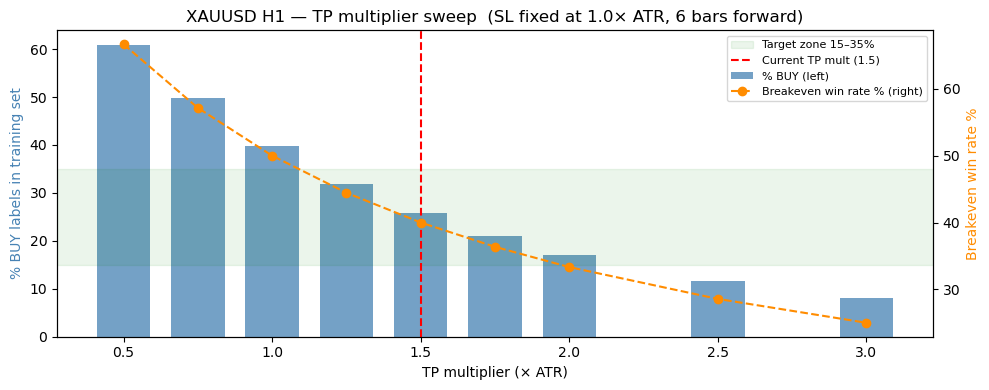

In [12]:
def _label_rate(features_df, train_start, train_end, forward_bars, tp_mult, sl_mult):
    """
    Lightweight helper: compute % BUY labels for a given multiplier pair.
    Labels are generated on the full feature set (so boundary rows are complete),
    then filtered to the training window for the balance calculation.
    """
    close = features_df["close"].values
    high  = features_df["high"].values
    low   = features_df["low"].values
    atr   = features_df["atr_14"].values
    n     = len(features_df)

    labels = np.full(n, np.nan)
    for i in range(n - forward_bars):
        tp_level = close[i] + atr[i] * tp_mult
        sl_level = close[i] - atr[i] * sl_mult
        result = 0
        for j in range(1, forward_bars + 1):
            k = i + j
            tp_hit = high[k] >= tp_level
            sl_hit = low[k]  <= sl_level
            if tp_hit and sl_hit:
                result = 0; break
            elif tp_hit:
                result = 1; break
            elif sl_hit:
                result = 0; break
        labels[i] = result

    # Filter to train window only
    mask  = (features_df["datetime"] >= train_start) & (features_df["datetime"] <= train_end)
    train_labels = labels[mask.values]
    valid = train_labels[~np.isnan(train_labels)]
    return valid.mean() * 100   # % BUY


# ── 1-D sweep: vary TP multiplier, fix SL = 1.0 ──────────────────────────────
tp_candidates = [0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]
sl_fixed      = 1.0

print(f"Fixed SL multiplier = {sl_fixed}\n")
print(f"{'TP mult':>8}  {'R:R':>6}  {'% BUY':>7}  {'Breakeven':>10}  {'In target?':>11}")
print("-" * 55)

tp_sweep_results = []
for tp in tp_candidates:
    pct_buy    = _label_rate(df_features, TRAIN_START, TRAIN_END, FORWARD_BARS, tp, sl_fixed)
    rr         = tp / sl_fixed
    breakeven  = sl_fixed / (tp + sl_fixed) * 100
    in_target  = "✓" if 15 <= pct_buy <= 35 else "✗"
    tp_sweep_results.append((tp, rr, pct_buy, breakeven))
    print(f"{tp:>8.2f}  {rr:>6.2f}  {pct_buy:>6.1f}%  {breakeven:>9.1f}%  {in_target:>11}")

# ── Chart ─────────────────────────────────────────────────────────────────────
tps, rrs, pcts, bes = zip(*tp_sweep_results)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

bars = ax1.bar(tps, pcts, width=0.18, color="steelblue", alpha=0.75, label="% BUY (left)")
ax1.axhspan(15, 35, alpha=0.08, color="green", label="Target zone 15–35%")
ax1.axvline(ATR_TP_MULT, color="red", linestyle="--", linewidth=1.5, label=f"Current TP mult ({ATR_TP_MULT})")
ax2.plot(tps, bes, "o--", color="darkorange", linewidth=1.5, label="Breakeven win rate % (right)")

ax1.set_xlabel("TP multiplier (× ATR)")
ax1.set_ylabel("% BUY labels in training set", color="steelblue")
ax2.set_ylabel("Breakeven win rate %", color="darkorange")
ax1.set_title(f"{PAIR} {TIMEFRAME} — TP multiplier sweep  (SL fixed at {sl_fixed}× ATR, {FORWARD_BARS} bars forward)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()


Computing grid (may take ~20 seconds)...
Done.



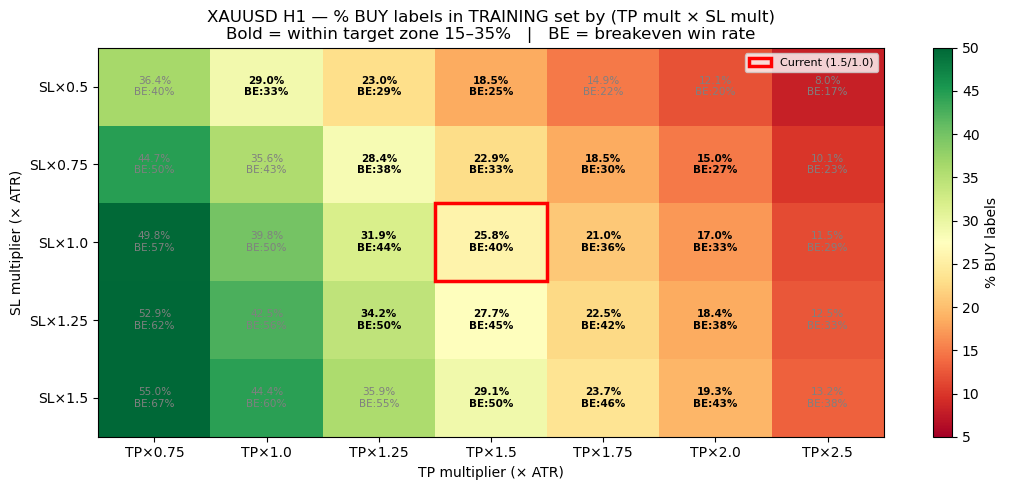


Reading the grid:
  Green cell  = high % BUY  |  Red cell = low % BUY
  Bold values = within target zone (15–35%) — safe to use
  BE          = min precision the model must achieve to be profitable

Current config: TP×1.5 / SL×1.0  →  R:R = 1.5  |  Breakeven = 40.0%


In [13]:
# ── 2-D grid: vary both TP and SL multipliers ────────────────────────────────
tp_grid = [0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5]
sl_grid = [0.5,  0.75, 1.0, 1.25, 1.5]

grid_pct = np.zeros((len(sl_grid), len(tp_grid)))

print("Computing grid (may take ~20 seconds)...")
for i, sl in enumerate(sl_grid):
    for j, tp in enumerate(tp_grid):
        grid_pct[i, j] = _label_rate(
            df_features, TRAIN_START, TRAIN_END, FORWARD_BARS, tp, sl
        )
print("Done.\n")

# ── Heatmap ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

im = ax.imshow(grid_pct, cmap="RdYlGn", vmin=5, vmax=50, aspect="auto")
plt.colorbar(im, ax=ax, label="% BUY labels")

# Annotate each cell with the % value and a breakeven marker
for i, sl in enumerate(sl_grid):
    for j, tp in enumerate(tp_grid):
        pct = grid_pct[i, j]
        be  = sl / (tp + sl) * 100
        in_range = 15 <= pct <= 35
        cell_text = f"{pct:.1f}%\nBE:{be:.0f}%"
        color = "black" if in_range else "grey"
        weight = "bold" if in_range else "normal"
        ax.text(j, i, cell_text, ha="center", va="center",
                fontsize=7.5, color=color, fontweight=weight)

# Mark the currently selected multipliers
if ATR_TP_MULT in tp_grid and ATR_SL_MULT in sl_grid:
    ci = sl_grid.index(ATR_SL_MULT)
    cj = tp_grid.index(ATR_TP_MULT)
    ax.add_patch(plt.Rectangle((cj - 0.5, ci - 0.5), 1, 1,
                                fill=False, edgecolor="red", linewidth=2.5,
                                label=f"Current ({ATR_TP_MULT}/{ATR_SL_MULT})"))
    ax.legend(loc="upper right", fontsize=8)

ax.set_xticks(range(len(tp_grid)))
ax.set_xticklabels([f"TP×{v}" for v in tp_grid])
ax.set_yticks(range(len(sl_grid)))
ax.set_yticklabels([f"SL×{v}" for v in sl_grid])
ax.set_xlabel("TP multiplier (× ATR)")
ax.set_ylabel("SL multiplier (× ATR)")
ax.set_title(
    f"{PAIR} {TIMEFRAME} — % BUY labels in TRAINING set by (TP mult × SL mult)\n"
    f"Bold = within target zone 15–35%   |   BE = breakeven win rate"
)
plt.tight_layout()
plt.show()

print("\nReading the grid:")
print("  Green cell  = high % BUY  |  Red cell = low % BUY")
print("  Bold values = within target zone (15–35%) — safe to use")
print("  BE          = min precision the model must achieve to be profitable")
print(f"\nCurrent config: TP×{ATR_TP_MULT} / SL×{ATR_SL_MULT}  →  "
      f"R:R = {ATR_TP_MULT/ATR_SL_MULT:.1f}  |  "
      f"Breakeven = {ATR_SL_MULT/(ATR_TP_MULT+ATR_SL_MULT)*100:.1f}%")


## 6. Label Generation — Y₁ (SELL)

### What exactly are we predicting?

For each H1 bar `t`, we simulate entering a **short trade at `close[t]`** and ask:  
*"Would this trade have hit Take Profit before Stop Loss within the next N bars?"*

### Label mechanics (mirror of the BUY model)

| Parameter | Formula | Example (ATR = 0.0008) |
|---|---|---|
| Entry price | `close[t]` | 1.0800 |
| TP level | `close[t] − ATR_14[t] × 1.5` | 1.0800 − 0.0012 = **1.0788** |
| SL level | `close[t] + ATR_14[t] × 1.0` | 1.0800 + 0.0008 = **1.0808** |
| Forward window | bars `t+1` → `t+N` | next N H1 bars |

Each bar in the window is checked in order (t+1 first):

```
low[t+j]  ≤ TP  AND  high[t+j] ≥ SL  → same-bar ambiguity → label = 0  (conservative)
low[t+j]  ≤ TP  (only)               → TP hit first       → label = 1  ✓  (short won)
high[t+j] ≥ SL  (only)               → SL hit first       → label = 0  ✗  (short lost)
neither hit in all N bars             → no outcome         → label = 0
```

**label = 1** → "SELL opportunity — this short trade would have been profitable"  
**label = 0** → "Not a SELL opportunity" (SL hit, timeout, or ambiguous bar)

### Risk-to-reward ratio
$$R:R = \frac{ATR\_TP\_MULT}{ATR\_SL\_MULT} = \frac{1.5}{1.0} = 1.5$$

The threshold is **adaptive per bar** — it scales with ATR, so a label-1 in a volatile session
requires a bigger move than in a quiet session.

### Why label the full dataset then split?
The label for bar `t` uses only the raw `high`/`low` of future bars as the **outcome** to predict.
Those future values never appear as model input features (all features are backward-looking).
There is no data leakage. The last `FORWARD_BARS` rows get `NaN` labels (no complete window) and are dropped.


In [14]:
def generate_sell_labels(
    data: pd.DataFrame,
    forward_bars: int,
    atr_tp_mult: float,
    atr_sl_mult: float,
) -> pd.DataFrame:
    """
    Generate binary SELL labels for each bar using a forward SL/TP scan.

    Mirror of generate_buy_labels — TP is BELOW entry, SL is ABOVE entry.

    Parameters
    ----------
    data         : DataFrame with columns close, high, low, atr_14 (sorted oldest→newest)
    forward_bars : how many H1 bars ahead to look for TP or SL hit
    atr_tp_mult  : TP = close[t] - atr_14[t] * atr_tp_mult  (price must fall here)
    atr_sl_mult  : SL = close[t] + atr_14[t] * atr_sl_mult  (price must NOT rise here)

    Returns
    -------
    DataFrame with a new column `sell_label` (1.0 or 0.0).
    The last `forward_bars` rows (NaN labels) are dropped.
    """
    df = data.copy()
    n = len(df)

    close = df["close"].values
    high  = df["high"].values
    low   = df["low"].values
    atr   = df["atr_14"].values

    labels = np.full(n, np.nan)

    for i in range(n - forward_bars):
        entry    = close[i]
        tp_level = entry - atr[i] * atr_tp_mult   # price must FALL to this level to win
        sl_level = entry + atr[i] * atr_sl_mult   # price must NOT rise to this level first

        result = 0   # default: label = 0 (no sell / timeout)

        for j in range(1, forward_bars + 1):
            k = i + j
            tp_hit = low[k]  <= tp_level   # short TP hit: price fell far enough
            sl_hit = high[k] >= sl_level   # short SL hit: price rose against the trade

            if tp_hit and sl_hit:
                # Both extremes on the same bar — can't tell which came first.
                # Conservative: assume SL hit first → not a clean sell.
                result = 0
                break
            elif tp_hit:
                result = 1   # TP reached before SL → valid sell opportunity
                break
            elif sl_hit:
                result = 0   # SL triggered before TP → trade would have lost
                break

        labels[i] = result

    df["sell_label"] = labels

    n_before = len(df)
    df.dropna(subset=["sell_label"], inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"Rows with complete label : {len(df):,}  (dropped {n_before - len(df)} tail rows)")

    return df


## 7. Chronological Split — Train / Validation / Test

Labels are generated first on the full `df_features`, then the dataset is split by date.
This is the correct order — labels use future price as the **target**, not as a feature,
so there is no data leakage.

| Set | Period | Purpose |
|---|---|---|
| **Train** | 2019-01-01 → 2024-12-31 | Model fitting |
| **Validation** | 2025-01-01 → 2025-12-31 | Model selection, threshold validation |
| **Test** | 2026-01-01 → present | Final hold-out — open only once at the very end |

> Split dates are defined in the **Configuration** cell — change them there, not here.


In [15]:
# Split date constants are defined in the Configuration cell (cell 4).
# The final labeled splits (df_train, df_val, df_test) are created in the cell below
# after labels have been generated — that is the only version used for training.
print(f"Train  : {TRAIN_START}  →  {TRAIN_END}")
print(f"Val    : {VAL_START}  →  {VAL_END}")
print(f"Test   : {TEST_START}  →  present")


Train  : 2020-06-30 00:00:00  →  2025-06-30 23:00:00
Val    : 2025-07-01 00:00:00  →  2025-12-31 23:00:00
Test   : 2026-01-01 00:00:00  →  present


Rows with complete label : 44,717  (dropped 6 tail rows)

=== Class balance ===
Split          Total   label=1   label=0   % Sell
--------------------------------------------------
Train         29,569     7,367    22,202    24.9%
Validation     2,999       760     2,239    25.3%
Test           3,671     1,083     2,588    29.5%
All           44,717    11,243    33,474    25.1%


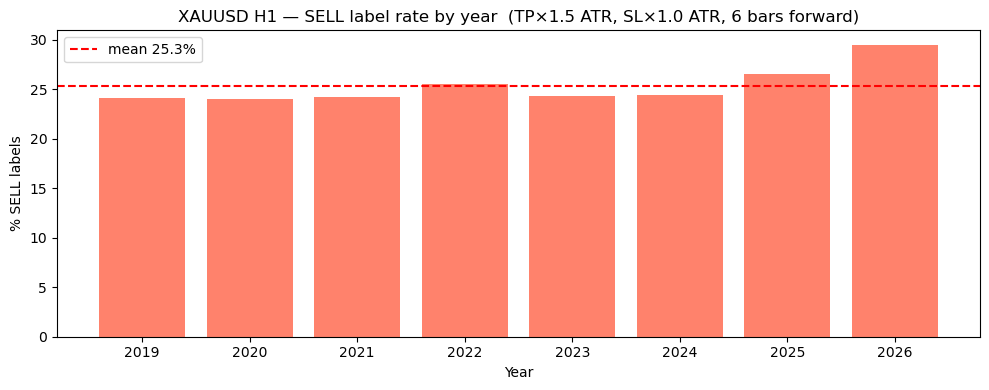

In [16]:
# ── Generate labels on the full feature dataset ───────────────────────────────
df_labeled = generate_sell_labels(
    df_features,
    forward_bars = FORWARD_BARS,
    atr_tp_mult  = ATR_TP_MULT,
    atr_sl_mult  = ATR_SL_MULT,
)

# ── Re-apply chronological splits now that labels exist ──────────────────────
df_train = df_labeled[(df_labeled["datetime"] >= TRAIN_START) & (df_labeled["datetime"] <= TRAIN_END)].copy().reset_index(drop=True)
df_val   = df_labeled[(df_labeled["datetime"] >= VAL_START)   & (df_labeled["datetime"] <= VAL_END)].copy().reset_index(drop=True)
df_test  = df_labeled[df_labeled["datetime"]  >= TEST_START].copy().reset_index(drop=True)

# ── Class balance check ───────────────────────────────────────────────────────
# Target: ~20-30% label=1. Too low → model never fires. Too high → labels are noise.
print("\n=== Class balance ===")
print(f"{'Split':<12} {'Total':>7}  {'label=1':>8}  {'label=0':>8}  {'% Sell':>7}")
print("-" * 50)
for split_name, split_df in [("Train", df_train), ("Validation", df_val), ("Test", df_test), ("All", df_labeled)]:
    n      = len(split_df)
    n_sell = int(split_df["sell_label"].sum())
    n_no   = n - n_sell
    pct    = n_sell / n * 100
    print(f"{split_name:<12} {n:>7,}  {n_sell:>8,}  {n_no:>8,}  {pct:>6.1f}%")

# ── Visual check: label distribution by year ─────────────────────────────────
df_labeled["year"] = df_labeled["datetime"].dt.year
yearly = df_labeled.groupby("year")["sell_label"].agg(["sum", "count"])
yearly["pct_sell"] = yearly["sum"] / yearly["count"] * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(yearly.index, yearly["pct_sell"], color="tomato", alpha=0.8)
ax.axhline(yearly["pct_sell"].mean(), color="red", linestyle="--", label=f"mean {yearly['pct_sell'].mean():.1f}%")
ax.set_xlabel("Year")
ax.set_ylabel("% SELL labels")
ax.set_title(f"{PAIR} {TIMEFRAME} — SELL label rate by year  (TP×{ATR_TP_MULT} ATR, SL×{ATR_SL_MULT} ATR, {FORWARD_BARS} bars forward)")
ax.legend()
plt.tight_layout()
plt.show()

df_labeled.drop(columns=["year"], inplace=True)


## 8. Training Process

### 8.1 Feature selection

**Method — noise features + voting system.**

We inject random *noise* features (columns with no real predictive value) alongside the
real features, then train several models and read their feature importances. Any real
feature that scores **below the noise** is useless and gets dropped.

Three models vote independently:
- **Random Forest** (tree importance)
- **LightGBM** (tree importance)
- **Logistic Regression** (scaled — `|coef|` as importance)

A feature is kept only if it consistently beats the noise across the models/strategies.

> Everything here is fit on **`df_train` only**. Validation and test sets are never touched
> during feature selection — otherwise we would leak future information.


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb

# ── Build the feature list ────────────────────────────────────────────────────
# Everything except raw OHLCV, datetime and the label is a candidate feature.
NON_FEATURES = ["datetime", "open", "high", "low", "close", "volume", "sell_label"]
feature_cols = [c for c in df_train.columns if c not in NON_FEATURES]

# Training matrix — TRAIN SET ONLY
X_train = df_train[feature_cols].copy()
y_train = df_train["sell_label"].astype(int)

print(f"Real features : {len(feature_cols)}")
print(f"X_train shape : {X_train.shape}")
print(f"Positive rate : {y_train.mean()*100:.1f}%")

# ── Generate noise features ───────────────────────────────────────────────────
# Random columns with no real signal. If a real feature can't beat these, drop it.
np.random.seed(42)
n = len(X_train)

noise = {
    "noise_gaussian_1": np.random.normal(0, 1, n),
    "noise_gaussian_2": np.random.normal(0, 2, n),
    "noise_gaussian_3": np.random.normal(5, 1, n),
    "noise_uniform_1":  np.random.uniform(-1, 1, n),
    "noise_uniform_2":  np.random.uniform(-10, 10, n),
    "noise_poisson_1":  np.random.poisson(3, n),
    "noise_poisson_2":  np.random.poisson(6, n),
    "noise_random_walk": np.cumsum(np.random.normal(0, 1, n)),
    "noise_sinusoidal": np.sin(np.linspace(0, 10, n)) + np.random.normal(0, 0.1, n),
}
noise_features = list(noise.keys())

# X augmented with the noise columns
X_noise = X_train.copy()
for name, values in noise.items():
    X_noise[name] = values

print(f"Noise features added : {len(noise_features)}")
print(f"X_noise shape        : {X_noise.shape}")


Real features : 104
X_train shape : (29569, 104)
Positive rate : 24.9%
Noise features added : 9
X_noise shape        : (29569, 113)


In [18]:
# ── Train three models to extract feature importances ─────────────────────────
# class_weight="balanced" handles the ~30/70 imbalance without resampling.

# 1) Random Forest
print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=200, max_depth=15, min_samples_split=10, min_samples_leaf=5,
    max_features="sqrt", class_weight="balanced", random_state=42, n_jobs=3,
)
rf.fit(X_noise, y_train)

# 2) LightGBM
print("Training LightGBM...")
lgbm = lgb.LGBMClassifier(
    n_estimators=250, max_depth=10, learning_rate=0.05, num_leaves=63,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    class_weight="balanced", random_state=42, verbose=-1,
)
lgbm.fit(X_noise, y_train)

# 3) Logistic Regression (linear) — needs scaling + NaN-free input.
#    Coefficients are only comparable when features are on the same scale.
print("Training Logistic Regression...")
X_scaled = X_noise.fillna(X_noise.median()).fillna(0)
scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_scaled), columns=X_noise.columns)

logreg = LogisticRegression(
    C=1.0, max_iter=2000, class_weight="balanced", random_state=42,
)
logreg.fit(X_scaled, y_train)

print("✓ All 3 models trained")

# ── Collect importances (one score per feature, per model) ────────────────────
rf_imp     = rf.feature_importances_
lgbm_imp   = lgbm.feature_importances_
logreg_imp = np.abs(logreg.coef_).ravel()   # |coefficient| = linear importance


Training Random Forest...
Training LightGBM...


c:\Users\david\anaconda3\Library\envs\deaf_agent\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\david\anaconda3\Library\envs\deaf_agent\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\david\anaconda3\Library\envs\deaf_agent\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\david\anaconda3\Library\envs\deaf_agent\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\david\ana

Training Logistic Regression...
✓ All 3 models trained


In [19]:
# ── Build the importance table ────────────────────────────────────────────────
imp_df = pd.DataFrame({
    "feature":     X_noise.columns,
    "rf_imp":      rf_imp,
    "lgbm_imp":    lgbm_imp,
    "logreg_imp":  logreg_imp,
})
imp_df["is_noise"] = imp_df["feature"].isin(noise_features)

# Weighted average — trees are more reliable here, so they get more weight.
imp_df["avg_imp"] = 0.3 * imp_df["rf_imp"] + 0.6 * imp_df["lgbm_imp"] + 0.1 * imp_df["logreg_imp"]
imp_df = imp_df.sort_values("avg_imp", ascending=False).reset_index(drop=True)

# ── Voting system ─────────────────────────────────────────────────────────────
# Each model "votes" for a feature if its importance is above the given percentile.
VOTING_PERCENTILE = 60   # R9: looser gate keeps more candidate features   # lower = more inclusive, higher = stricter

rf_thr     = np.percentile(rf_imp, VOTING_PERCENTILE)
lgbm_thr   = np.percentile(lgbm_imp, VOTING_PERCENTILE)
logreg_thr = np.percentile(logreg_imp, VOTING_PERCENTILE)

imp_df["rf_vote"]     = (imp_df["rf_imp"]     >= rf_thr).astype(int)
imp_df["lgbm_vote"]   = (imp_df["lgbm_imp"]   >= lgbm_thr).astype(int)
imp_df["logreg_vote"] = (imp_df["logreg_imp"] >= logreg_thr).astype(int)
imp_df["total_votes"] = imp_df[["rf_vote", "lgbm_vote", "logreg_vote"]].sum(axis=1)

print(f"Voting thresholds (top {VOTING_PERCENTILE}%):  "
      f"RF={rf_thr:.5f}  LGBM={lgbm_thr:.5f}  LogReg={logreg_thr:.5f}\n")
print("Top 10 features by average importance:")
print(imp_df[["feature", "avg_imp", "total_votes", "is_noise"]].head(10).to_string(index=False))


Voting thresholds (top 60%):  RF=0.00934  LGBM=134.00000  LogReg=0.04592

Top 10 features by average importance:
              feature    avg_imp  total_votes  is_noise
    deviation_sum_24h 235.204288            2     False
        vix_change_1d 219.608480            3     False
hours_since_last_high 210.005117            2     False
           dxy_ret_1d 205.806798            2     False
    tips10y_change_5d 199.807507            2     False
               d1_rsi 193.812338            3     False
    tips10y_zscore_20 192.006452            2     False
           atr_regime 190.828897            3     False
               adx_14 187.207174            2     False
    noise_random_walk 183.609531            3      True


In [20]:
# ── Noise benchmark ───────────────────────────────────────────────────────────
noise_df = imp_df[imp_df["is_noise"]]
real_df  = imp_df[~imp_df["is_noise"]]

noise_imp_mean = noise_df["avg_imp"].mean()
noise_imp_std  = noise_df["avg_imp"].std()
noise_imp_p70  = np.percentile(noise_df["avg_imp"], 70)
noise_votes_max = noise_df["total_votes"].max()

print(f"Noise benchmark — mean:{noise_imp_mean:.5f}  p70:{noise_imp_p70:.5f}  "
      f"max_votes:{noise_votes_max}\n")

# ── Five selection strategies (each returns a set of real features) ───────────
# A feature that survives several of these is very likely genuine signal.
best_noise_rank = imp_df[imp_df["is_noise"]].index.min()   # rank of top noise feature

strategies = {
    # 1) Ranked above the single best noise feature
    "better_than_best_noise": set(
        real_df[real_df.index < best_noise_rank]["feature"]
    ),
    # 2) Importance above the 70th percentile of noise
    "above_noise_p70": set(
        real_df[real_df["avg_imp"] > noise_imp_p70]["feature"]
    ),
    # 3) More votes than the best noise feature
    "more_votes_than_noise": set(
        real_df[real_df["total_votes"] > noise_votes_max]["feature"]
    ),
    # 4) Above statistical threshold (noise mean + 0.5 std)
    "statistical_threshold": set(
        real_df[real_df["avg_imp"] > noise_imp_mean + 0.5 * noise_imp_std]["feature"]
    ),
    # 5) At least one vote AND above noise mean
    "vote_and_above_mean": set(
        real_df[(real_df["total_votes"] >= 1) & (real_df["avg_imp"] > noise_imp_mean)]["feature"]
    ),
}

for name, feats in strategies.items():
    print(f"  {name:<25} {len(feats)} features")

# ── Consensus — count how many strategies support each feature ────────────────
support = {}
for feats in strategies.values():
    for f in feats:
        support[f] = support.get(f, 0) + 1

MIN_STRATEGY_SUPPORT = 3   # keep features backed by at least this many strategies
selected_features = sorted(
    [f for f, s in support.items() if s >= MIN_STRATEGY_SUPPORT],
    key=lambda f: imp_df.loc[imp_df["feature"] == f, "avg_imp"].iloc[0],
    reverse=True,
)

# Safety net: make sure noise never slips through
selected_features = [f for f in selected_features if f not in noise_features]

print(f"\n✓ Selected features (≥{MIN_STRATEGY_SUPPORT} strategies): {len(selected_features)}")


Noise benchmark — mean:75.67124  p70:71.40250  max_votes:3

  better_than_best_noise    9 features
  above_noise_p70           52 features
  more_votes_than_noise     0 features
  statistical_threshold     32 features
  vote_and_above_mean       47 features

✓ Selected features (≥3 strategies): 32


FEATURE SELECTION RESULTS
Real features tested : 104
Selected             : 32
Reduction            : 69%
Best noise importance : 183.60953

Top 15 selected features:
              feature    avg_imp  total_votes
    deviation_sum_24h 235.204288            2
        vix_change_1d 219.608480            3
hours_since_last_high 210.005117            2
           dxy_ret_1d 205.806798            2
    tips10y_change_5d 199.807507            2
               d1_rsi 193.812338            3
    tips10y_zscore_20 192.006452            2
           atr_regime 190.828897            3
               adx_14 187.207174            2
       rolling_std_50 183.010434            3
                  obv 177.613538            3
        vix_zscore_20 174.005612            2
      close_vs_ema200 169.230027            3
         obv_slope_20 168.008093            3
        vix_change_5d 165.604341            2

Noise feature positions (for reference):
          feature    avg_imp  total_votes
noise_random_

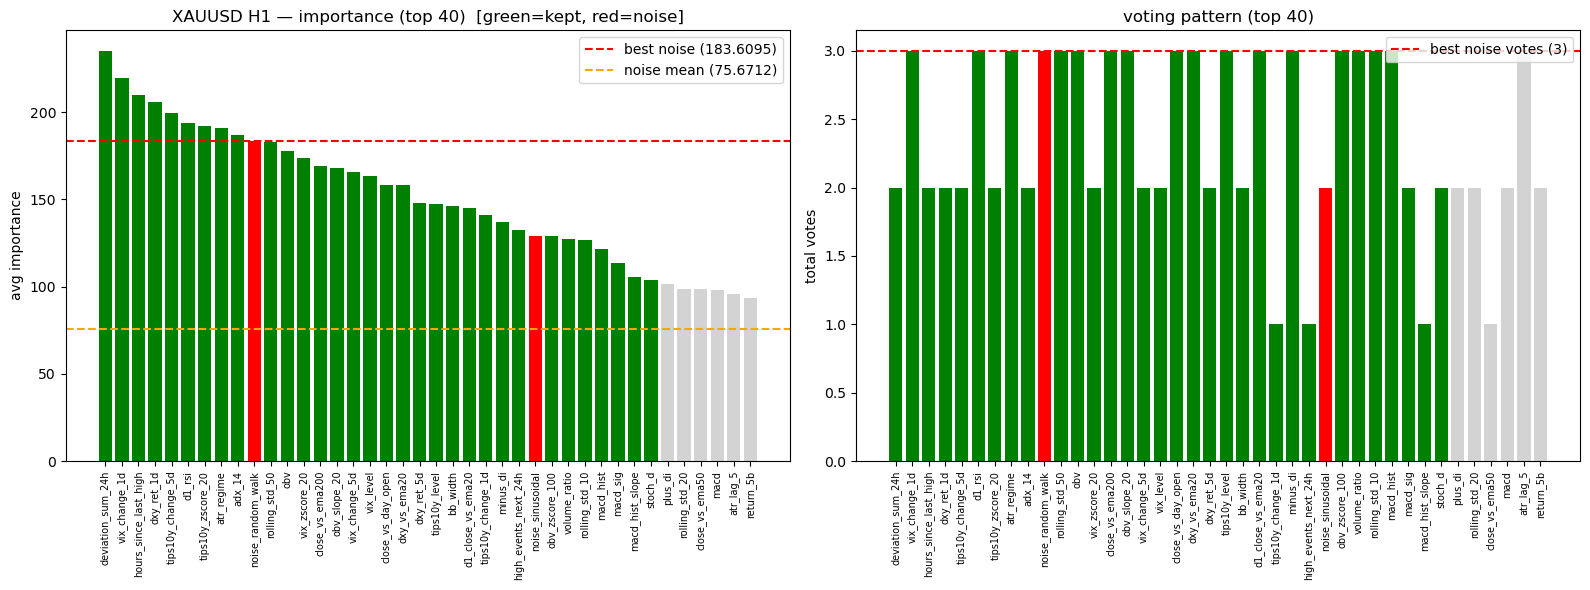

In [21]:
# ── Report ────────────────────────────────────────────────────────────────────
print("=" * 60)
print("FEATURE SELECTION RESULTS")
print("=" * 60)
print(f"Real features tested : {len(feature_cols)}")
print(f"Selected             : {len(selected_features)}")
print(f"Reduction            : {(1 - len(selected_features)/len(feature_cols))*100:.0f}%")
print(f"Best noise importance : {noise_df['avg_imp'].max():.5f}")

selected_report = imp_df[imp_df["feature"].isin(selected_features)]

print("\nTop 15 selected features:")
print(selected_report[["feature", "avg_imp", "total_votes"]].head(15).to_string(index=False))

print("\nNoise feature positions (for reference):")
print(noise_df[["feature", "avg_imp", "total_votes"]].to_string(index=False))

# ── Visualization ─────────────────────────────────────────────────────────────
top = imp_df.head(40)
colors = [
    "green" if f in selected_features else ("red" if noise else "lightgray")
    for f, noise in zip(top["feature"], top["is_noise"])
]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(16, 6))

# Left: average importance, with noise benchmarks
axL.bar(range(len(top)), top["avg_imp"], color=colors)
axL.axhline(noise_df["avg_imp"].max(), color="red", linestyle="--",
            label=f"best noise ({noise_df['avg_imp'].max():.4f})")
axL.axhline(noise_imp_mean, color="orange", linestyle="--",
            label=f"noise mean ({noise_imp_mean:.4f})")
axL.set_xticks(range(len(top)))
axL.set_xticklabels(top["feature"], rotation=90, fontsize=7)
axL.set_ylabel("avg importance")
axL.set_title(f"{PAIR} {TIMEFRAME} — importance (top 40)  [green=kept, red=noise]")
axL.legend()

# Right: votes
axR.bar(range(len(top)), top["total_votes"], color=colors)
axR.axhline(noise_votes_max, color="red", linestyle="--",
            label=f"best noise votes ({noise_votes_max})")
axR.set_xticks(range(len(top)))
axR.set_xticklabels(top["feature"], rotation=90, fontsize=7)
axR.set_ylabel("total votes")
axR.set_title("voting pattern (top 40)")
axR.legend()

plt.tight_layout()
plt.show()


In [22]:
selected_features

['deviation_sum_24h',
 'vix_change_1d',
 'hours_since_last_high',
 'dxy_ret_1d',
 'tips10y_change_5d',
 'd1_rsi',
 'tips10y_zscore_20',
 'atr_regime',
 'adx_14',
 'rolling_std_50',
 'obv',
 'vix_zscore_20',
 'close_vs_ema200',
 'obv_slope_20',
 'vix_change_5d',
 'vix_level',
 'close_vs_day_open',
 'dxy_vs_ema20',
 'dxy_ret_5d',
 'tips10y_level',
 'bb_width',
 'd1_close_vs_ema20',
 'tips10y_change_1d',
 'minus_di',
 'high_events_next_24h',
 'obv_zscore_100',
 'volume_ratio',
 'rolling_std_10',
 'macd_hist',
 'macd_sig',
 'macd_hist_slope',
 'stoch_d']

In [23]:
# ── Persist the selection for the training phase ──────────────────────────────
# Save both the chosen list and the full importance report next to the model bin.
FEATURES_DIR = ROOT / "data" / "features"
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

selected_report.to_csv(FEATURES_DIR / f"{PAIR}_{TIMEFRAME}_selected_features.csv", index=False)
imp_df.to_csv(FEATURES_DIR / f"{PAIR}_{TIMEFRAME}_feature_importance_full.csv", index=False)

print(f"✓ Saved {len(selected_features)} selected features to:")
print(f"  {FEATURES_DIR / f'{PAIR}_{TIMEFRAME}_selected_features.csv'}")

# Keep in memory for the next step (model training uses selected_features)
print(f"\nselected_features ready for training ({len(selected_features)} columns).")


✓ Saved 32 selected features to:
  C:\Users\david\OneDrive\Documents\fx-prival\ml-signal-service\data\features\XAUUSD_H1_selected_features.csv

selected_features ready for training (32 columns).


In [24]:
selected_report

,feature,rf_imp,lgbm_imp,logreg_imp,is_noise,avg_imp,rf_vote,lgbm_vote,logreg_vote,total_votes
0,deviation_sum_24h,0.011148,392,0.009436,False,235.204288,1,1,0,2
1,vix_change_1d,0.011411,366,0.050569,False,219.608480,1,1,1,3
2,hours_since_last_high,0.014643,350,0.007244,False,210.005117,1,1,0,2
3,dxy_ret_1d,0.011680,343,0.032935,False,205.806798,1,1,0,2
4,tips10y_change_5d,0.010035,333,0.044967,False,199.807507,1,1,0,2
5,d1_rsi,0.011566,323,0.088678,False,193.812338,1,1,1,3
6,tips10y_zscore_20,0.011580,320,0.029779,False,192.006452,1,1,0,2
7,atr_regime,0.028889,318,0.202306,False,190.828897,1,1,1,3
8,adx_14,0.010916,312,0.038995,False,187.207174,1,1,0,2
10,rolling_std_50,0.011750,305,0.069088,False,183.010434,1,1,1,3


### 8.2 Model Selection

We pick the best classifier with **nested cross-validation** — an unbiased way to compare models
that also tunes hyperparameters without leaking the validation/test data.

- **Outer CV** — `GroupKFold` by *year* → no year appears in both train and eval within a fold.
- **Inner CV** — `TimeSeriesSplit` → hyperparameter search respects time order.
- **Recency weights** — recent years get more influence (markets drift over time).
- **Optimization metric** — **PR-AUC** (average precision), the right target for an imbalanced,
  precision-focused BUY signal.

Progression: **Logistic Regression** (baseline) → **Random Forest** → **XGBoost** → **LightGBM**.
The model with the best mean outer-fold PR-AUC wins.


In [25]:
# ── Build model matrices from the selected features ───────────────────────────
X_train = df_train[selected_features].fillna(0)
y_train = df_train["sell_label"].astype(int)

X_val = df_val[selected_features].fillna(0)
y_val = df_val["sell_label"].astype(int)

X_test = df_test[selected_features].fillna(0)
y_test = df_test["sell_label"].astype(int)

# ── Purged expanding TimeSeriesSplit (replaces GroupKFold by year) ─────────────
# Expanding windows with a 30-day embargo between train and test.
# Tests the skill that matters in production: training on the past, predicting
# the future. The embargo prevents label leakage from FORWARD_BARS scan and D1
# context shift(1) crossing fold boundaries.
# Assumes df_train is already sorted chronologically (standard after dropna).
train_dates = pd.to_datetime(df_train["datetime"])
n_train = len(df_train)

PURGE_DAYS = 30
OUTER_FOLDS = 4

outer_cv = []
fold_boundaries = []

block_size = n_train // (OUTER_FOLDS + 1)

for fold in range(OUTER_FOLDS):
    test_start_raw = block_size * (fold + 1)
    test_end_raw   = block_size * (fold + 2) if fold < OUTER_FOLDS - 1 else n_train

    # Purge: slide test_start forward until >= 30 calendar days after last train bar
    last_train_date = train_dates.iloc[test_start_raw - 1]
    purge_threshold = last_train_date + pd.Timedelta(days=PURGE_DAYS)

    test_start = test_start_raw
    while test_start < test_end_raw and train_dates.iloc[test_start] < purge_threshold:
        test_start += 1

    if test_end_raw - test_start < 50:
        continue   # fold too small to evaluate — skip

    train_idx = np.arange(0, test_start)
    test_idx  = np.arange(test_start, test_end_raw)
    outer_cv.append((train_idx, test_idx))
    fold_boundaries.append((train_dates.iloc[test_start], train_dates.iloc[test_end_raw - 1]))

# ── Recency sample weights ────────────────────────────────────────────────────
train_years = df_train["datetime"].dt.year.values

def time_decay_weights(years, decay=0.15):
    years_ago = years.max() - years
    w = np.exp(-decay * years_ago)
    return w * len(w) / w.sum()

sample_weights = time_decay_weights(train_years)

print(f"Features : {len(selected_features)}")
print(f"Train    : {X_train.shape}  (pos {y_train.mean()*100:.1f}%)")
print(f"Val      : {X_val.shape}  (pos {y_val.mean()*100:.1f}%)")
print(f"Test     : {X_test.shape}  (sealed)")
print(f"Years    : {sorted(set(train_years))}")
print(f"Outer CV : purged expanding TimeSeriesSplit ({len(outer_cv)} folds, {PURGE_DAYS}-day embargo)")
for i, (start, end) in enumerate(fold_boundaries):
    print(f"  fold {i+1} test: {start.strftime('%Y-%m-%d')} → {end.strftime('%Y-%m-%d')}")


Features : 32
Train    : (29569, 32)  (pos 24.9%)
Val      : (2999, 32)  (pos 25.3%)
Test     : (3671, 32)  (sealed)
Years    : [np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]
Outer CV : purged expanding TimeSeriesSplit (4 folds, 30-day embargo)
  fold 1 test: 2021-07-30 → 2022-06-29
  fold 2 test: 2022-07-29 → 2023-06-29
  fold 3 test: 2023-07-31 → 2024-06-28
  fold 4 test: 2024-07-29 → 2025-06-30


In [26]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from xgboost import XGBClassifier
# NOTE: Previous grid was over-regularised (max_depth=3-4, reg_lambda up to 5.0,
# learning_rate capped at 0.05). This effectively capped the model near linear-
# regression capacity. The grid below gives the search enough range to find the
# right bias-variance trade-off for this dataset: 26 features, ~40k H1 bars,
# ~24% positive class.

# scale_pos_weight balances XGBoost the way class_weight="balanced" does for the others
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "LogReg": {
        "model": Pipeline([
            ("scale", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
        ]),
        "params": {},   # baseline — no tuning
    },
    "RandomForest": {
        "model": RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=3),
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [10, 12, 15, 20],
            "min_samples_leaf": [5, 10, 20, 50],
            "max_features": ["sqrt", "log2", 0.5],
        },
    },
    "XGBoost": {
        "model": XGBClassifier(
            random_state=42, n_jobs=3, tree_method="hist",
            eval_metric="logloss", scale_pos_weight=pos_weight,
        ),
        "params": {
            "max_depth": [5, 7, 9, 11],
            "learning_rate": [0.05, 0.10, 0.20],
            "n_estimators": [100, 200, 300],
            "subsample": [0.7, 0.8, 0.9],
            "colsample_bytree": [0.7, 0.8, 0.9],
            "reg_lambda": [0.5, 1.0, 5.0],
        },
    },
    "LightGBM": {
        "model": lgb.LGBMClassifier(
            class_weight="balanced", random_state=42, n_jobs=3, verbose=-1,
        ),
        "params": {
            "max_depth": [6, 8, 10, 12],
            "num_leaves": [15, 31, 63],
            "learning_rate": [0.05, 0.10, 0.20],
            "n_estimators": [100, 200, 300],
            "subsample": [0.8, 0.9, 1.0],
            "colsample_bytree": [0.7, 0.8, 0.9],
            "reg_lambda": [0.1, 0.5, 1.0, 5.0],
            "min_child_samples": [10, 20, 50],
        },
    },
}

# ── CV strategy ───────────────────────────────────────────────────────────────
INNER_FOLDS = 5
SEARCH_ITERS = 20   # wider grid needs more draws to explore

inner_cv = TimeSeriesSplit(n_splits=INNER_FOLDS)

print(f"Inner CV : TimeSeriesSplit({INNER_FOLDS})")
print(f"Search   : {SEARCH_ITERS} iters | optimizing PR-AUC (average_precision)")
print(f"XGB scale_pos_weight = {pos_weight:.2f}")

Inner CV : TimeSeriesSplit(5)
Search   : 20 iters | optimizing PR-AUC (average_precision)
XGB scale_pos_weight = 3.01


In [27]:
from sklearn.metrics import average_precision_score


def nested_cv(model, params, X, y, weights, name):
    """
    Nested cross-validation for one classifier.
    Inner loop tunes hyperparameters (RandomizedSearchCV, PR-AUC).
    Outer loop uses purged expanding TimeSeriesSplit — train on past, test on future.
    Returns scores + best params per fold.
    """
    outer_scores, best_params_per_fold = [], []

    for fold, (tr, te) in enumerate(outer_cv, 1):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]
        w_tr = weights[tr]

        if params:  # tree models — tune hyperparameters on the inner split
            search = RandomizedSearchCV(
                model, params, n_iter=SEARCH_ITERS, cv=inner_cv,
                scoring="average_precision", n_jobs=3, random_state=42,
            )
            search.fit(X_tr, y_tr, sample_weight=w_tr)
            best = search.best_estimator_
            best_params_per_fold.append(search.best_params_)
        else:       # baseline — no tuning
            best = model.fit(X_tr, y_tr)
            best_params_per_fold.append({})

        # PR-AUC on the untouched outer fold
        proba = best.predict_proba(X_te)[:, 1]
        outer_scores.append(average_precision_score(y_te, proba))
        print(f"   fold {fold}/{len(outer_cv)}  PR-AUC = {outer_scores[-1]:.3f}")

    print(f"   → {name}: PR-AUC {np.mean(outer_scores):.3f} ± {np.std(outer_scores):.3f}")
    return {
        "name": name,
        "pr_auc_mean": np.mean(outer_scores),
        "pr_auc_std": np.std(outer_scores),
        "best_params_per_fold": best_params_per_fold,
    }


print("✓ nested_cv() ready")

✓ nested_cv() ready


In [28]:
# ── Run nested CV for every model ─────────────────────────────────────────────
# Note: the tree searches can take a few minutes.
cv_results = {}
for name, cfg in models.items():
    print(f"\n{name}")
    cv_results[name] = nested_cv(
        cfg["model"], cfg["params"], X_train, y_train, sample_weights, name,
    )

# ── Comparison table (higher PR-AUC is better) ────────────────────────────────
comparison = (
    pd.DataFrame([
        {"model": r["name"], "pr_auc": r["pr_auc_mean"], "std": r["pr_auc_std"]}
        for r in cv_results.values()
    ])
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)

# Baseline reference = prevalence (a random model scores ≈ positive rate)
baseline_pr = y_train.mean()

print("\n=== Model comparison (PR-AUC) ===")
print(comparison.round(3).to_string(index=False))
print(f"\nRandom baseline PR-AUC ≈ {baseline_pr:.3f} (positive rate)")

best_model_name = comparison.iloc[0]["model"]
print(f"\n🏆 Best model: {best_model_name}")


LogReg
   fold 1/4  PR-AUC = 0.307
   fold 2/4  PR-AUC = 0.332
   fold 3/4  PR-AUC = 0.310
   fold 4/4  PR-AUC = 0.298
   → LogReg: PR-AUC 0.312 ± 0.013

RandomForest
   fold 1/4  PR-AUC = 0.312


c:\Users\david\anaconda3\Library\envs\deaf_agent\Lib\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


   fold 2/4  PR-AUC = 0.352
   fold 3/4  PR-AUC = 0.293


c:\Users\david\anaconda3\Library\envs\deaf_agent\Lib\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


   fold 4/4  PR-AUC = 0.302
   → RandomForest: PR-AUC 0.315 ± 0.023

XGBoost
   fold 1/4  PR-AUC = 0.297
   fold 2/4  PR-AUC = 0.330
   fold 3/4  PR-AUC = 0.287
   fold 4/4  PR-AUC = 0.302
   → XGBoost: PR-AUC 0.304 ± 0.016

LightGBM
   fold 1/4  PR-AUC = 0.292
   fold 2/4  PR-AUC = 0.341
   fold 3/4  PR-AUC = 0.291
   fold 4/4  PR-AUC = 0.301
   → LightGBM: PR-AUC 0.306 ± 0.020

=== Model comparison (PR-AUC) ===
       model  pr_auc   std
RandomForest   0.315 0.023
      LogReg   0.312 0.013
    LightGBM   0.306 0.020
     XGBoost   0.304 0.016

Random baseline PR-AUC ≈ 0.249 (positive rate)

🏆 Best model: RandomForest


In [29]:
# ── Manual model override ─────────────────────────────────────────────────────
# By default the model with the best CV PR-AUC is used automatically.
# To force a different model, set MANUAL_MODEL to one of the names below and
# re-run this cell + everything after it.
#
# Available names (must match exactly):
#   "LogReg"        "RandomForest"        "XGBoost"        "LightGBM"
#
MANUAL_MODEL =  None        # ← change to e.g. "LightGBM" to override

# ── Apply override (or keep automatic winner) ─────────────────────────────────
if MANUAL_MODEL is not None:
    if MANUAL_MODEL not in cv_results:
        raise ValueError(f"Unknown model '{MANUAL_MODEL}'. Choose from: {list(cv_results.keys())}")
    best_model_name = MANUAL_MODEL
    print(f"⚠ Manual override active → using {best_model_name}")
else:
    print(f"✓ Auto-selected best model → {best_model_name}")

# Show the CV score for the chosen model
chosen = cv_results[best_model_name]
print(f"\n  CV PR-AUC : {chosen['pr_auc_mean']:.3f} ± {chosen['pr_auc_std']:.3f}")
print(f"\nModel comparison for reference:")
print(comparison.round(3).to_string(index=False))

✓ Auto-selected best model → RandomForest

  CV PR-AUC : 0.315 ± 0.023

Model comparison for reference:
       model  pr_auc   std
RandomForest   0.315 0.023
      LogReg   0.312 0.013
    LightGBM   0.306 0.020
     XGBoost   0.304 0.016


In [30]:
# ── Final model: isotonic calibration (R6) + optional soft-vote ensemble (R8) ──
from collections import Counter
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix,
)

# ── Toggles ───────────────────────────────────────────────────────────────────
USE_CALIBRATION = True    # R6: isotonic calibration -> reliable, monotonic probabilities
USE_ENSEMBLE    = True    # R8: average all four calibrated models instead of one winner
CALIB_CV        = 3       # internal CV folds for the calibrator (fit on TRAIN only)


def most_frequent_params(params_list):
    """Aggregate the hyperparameters most often chosen across the outer folds."""
    final = {}
    for key in {k for p in params_list for k in p}:
        vals = [p[key] for p in params_list if key in p]
        final[key] = Counter(vals).most_common(1)[0][0]
    return final


def build_tuned(name):
    """Fresh estimator for `name` with its most-frequent CV hyperparameters applied."""
    est = models[name]["model"]
    params = most_frequent_params(cv_results[name]["best_params_per_fold"])
    if params:
        est.set_params(**params)
    return est, params


def make_calibrated(est):
    """R6: wrap an estimator in isotonic calibration (internal CV on train)."""
    return CalibratedClassifierCV(est, method="isotonic", cv=CALIB_CV) if USE_CALIBRATION else est


# ── Assemble the final estimator (all sklearn -> picklable for the combiner) ──
if USE_ENSEMBLE:
    estimators = []
    for name in models:
        base, params = build_tuned(name)
        estimators.append((name, make_calibrated(base)))
        print(f"  {name:<12} params: {params if params else '(baseline)'}")
    final_model = VotingClassifier(estimators=estimators, voting="soft", n_jobs=3)
    final_model.fit(X_train, y_train)          # ensemble of pipelines -> fit without sample_weight
    best_model_name = "Ensemble"
    print("\n✓ Final model = soft-vote ensemble of 4 calibrated models")
else:
    base, params = build_tuned(best_model_name)
    final_model = make_calibrated(base)
    try:                                       # apply recency weights where supported
        final_model.fit(X_train, y_train, sample_weight=sample_weights)
    except TypeError:
        final_model.fit(X_train, y_train)
    print(f"Final hyperparameters: {params}")
    print(f"\n✓ Final model = {best_model_name}{' (calibrated)' if USE_CALIBRATION else ''}")

# ── Validation performance ────────────────────────────────────────────────────
val_proba = final_model.predict_proba(X_val)[:, 1]
val_pred  = (val_proba >= 0.5).astype(int)
breakeven = ATR_SL_MULT / (ATR_TP_MULT + ATR_SL_MULT)   # precision the model must beat

# NOTE: 0.5 is only a reference point — the true operating threshold is
# calibrated in the next cell. A well-calibrated model on a ~25% base-rate
# problem rarely exceeds 0.5, so these figures look conservative by design.
print(f"\n=== Validation performance (@0.5 reference) — {best_model_name} ===")
print(f"Precision : {precision_score(y_val, val_pred, zero_division=0):.3f}   (breakeven ≈ {breakeven:.3f})")
print(f"Recall    : {recall_score(y_val, val_pred, zero_division=0):.3f}")
print(f"F1        : {f1_score(y_val, val_pred, zero_division=0):.3f}")
print(f"ROC-AUC   : {roc_auc_score(y_val, val_proba):.3f}")
print(f"PR-AUC    : {average_precision_score(y_val, val_proba):.3f}")
print("\nConfusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_val, val_pred))


  LogReg       params: (baseline)
  RandomForest params: {'n_estimators': 100, 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 20}
  XGBoost      params: {'learning_rate': 0.05, 'reg_lambda': 5.0, 'max_depth': 9, 'n_estimators': 200, 'colsample_bytree': 0.7, 'subsample': 0.8}
  LightGBM     params: {'learning_rate': 0.1, 'reg_lambda': 5.0, 'max_depth': 8, 'num_leaves': 15, 'n_estimators': 100, 'colsample_bytree': 0.8, 'min_child_samples': 50, 'subsample': 0.9}

✓ Final model = soft-vote ensemble of 4 calibrated models

=== Validation performance (@0.5 reference) — Ensemble ===
Precision : 0.000   (breakeven ≈ 0.400)
Recall    : 0.000
F1        : 0.000
ROC-AUC   : 0.564
PR-AUC    : 0.305

Confusion matrix (rows=true, cols=pred):
[[2239    0]
 [ 760    0]]


### 8.3 Threshold Calibration

Precision at threshold 0.5 is **below the breakeven (0.40)** — the model fires on too many
low-confidence bars. Raising the threshold trades recall for precision.

We scan every threshold and find the one where **precision ≥ breakeven** with the most signals.


Breakeven          : 0.400
Min signals floor  : 50
Optimal threshold  : 0.324
Precision @ optimal: 0.483
Recall    @ optimal: 0.037
Signals            : 58 (0.46/day)

Top eligible thresholds:
 threshold  precision  recall  n_signals  signals_per_day
     0.324      0.483   0.037         58             0.46
     0.325      0.481   0.034         54             0.43
     0.324      0.475   0.037         59             0.47
     0.325      0.474   0.036         57             0.46
     0.325      0.473   0.034         55             0.44
     0.325      0.472   0.033         53             0.42
     0.324      0.467   0.037         60             0.48
     0.323      0.459   0.059         98             0.78
     0.325      0.464   0.034         56             0.45
     0.323      0.455   0.059         99             0.79


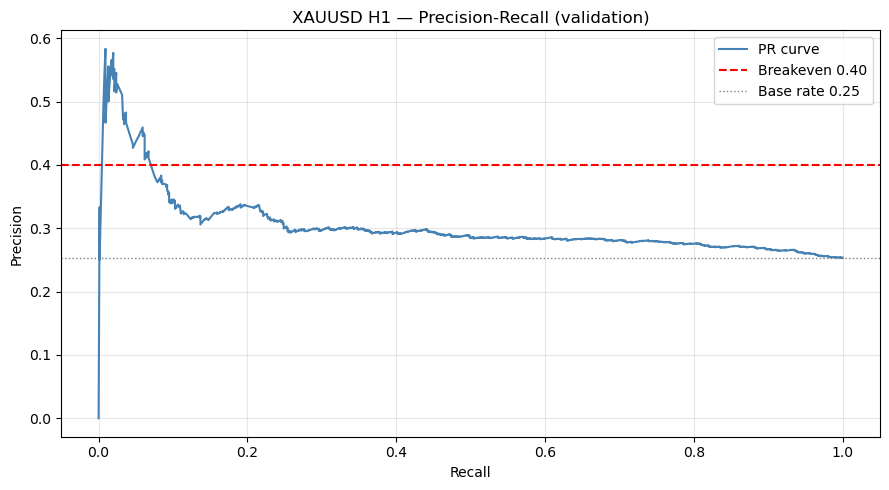

In [31]:
from sklearn.metrics import precision_recall_curve

# ── R1: threshold calibration with a minimum-support floor ────────────────────
# The old rule ("highest recall with precision >= breakeven") could latch onto a
# handful of lucky bars (e.g. 7 signals) that never generalize to the test set.
# We now require a minimum number of validation signals before a threshold is
# eligible, then pick the one maximizing precision x log(signals).
MIN_VAL_SIGNALS = 50    # ~0.5 signals/day over the validation window

precisions, recalls, thresholds = precision_recall_curve(y_val, val_proba)
trading_days = len(y_val) / 24

rows = []
for thr, prec, rec in zip(thresholds, precisions[:-1], recalls[:-1]):
    n_signals = int((val_proba >= thr).sum())
    if n_signals == 0:
        continue
    rows.append({
        "threshold": round(float(thr), 3),
        "precision": round(float(prec), 3),
        "recall":    round(float(rec), 3),
        "n_signals": n_signals,
        "signals_per_day": round(n_signals / trading_days, 2),
    })
cal_df = pd.DataFrame(rows)

eligible = cal_df[cal_df["n_signals"] >= MIN_VAL_SIGNALS].copy()
if not eligible.empty:
    above = eligible[eligible["precision"] >= breakeven]
    if not above.empty:
        # A profitable region exists. Because the strategy has a FIXED breakeven,
        # what drives EV is the precision MARGIN over breakeven — so rank by
        # (precision - breakeven) * log(signals). The log term keeps a mild reward
        # for volume without letting it override precision. This avoids the volume
        # bias of precision*log(signals), which picked SELL thr 0.295 (val prec 0.425)
        # over 0.306 (val prec 0.447); 0.295 then slipped to 0.391 (below breakeven)
        # on the sealed test, while the higher-precision 0.306 point holds up better.
        pool = above.assign(score=(above["precision"] - breakeven) * np.log(above["n_signals"]))
    else:
        # No threshold clears breakeven: the model is a pure ranker. Keep the old
        # volume-weighted pick and gate it downstream via the combiner EV/CI check.
        pool = eligible.assign(score=eligible["precision"] * np.log(eligible["n_signals"]))
    best  = pool.sort_values("score", ascending=False).iloc[0]
    OPTIMAL_THRESHOLD = float(best["threshold"])
    reached = best["precision"] >= breakeven
    print(f"Breakeven          : {breakeven:.3f}")
    print(f"Min signals floor  : {MIN_VAL_SIGNALS}")
    print(f"Optimal threshold  : {OPTIMAL_THRESHOLD}")
    note = "" if reached else "  ⚠ below breakeven — model is a ranker; gate downstream"
    print(f"Precision @ optimal: {best['precision']:.3f}{note}")
    print(f"Recall    @ optimal: {best['recall']:.3f}")
    print(f"Signals            : {int(best['n_signals'])} ({best['signals_per_day']:.2f}/day)")
    print("\nTop eligible thresholds:")
    print(pool.sort_values("score", ascending=False)
              .drop(columns="score").head(10).to_string(index=False))
else:
    OPTIMAL_THRESHOLD = 0.5
    print(f"⚠ No threshold reaches {MIN_VAL_SIGNALS} signals on validation — falling back to 0.5.")

# ── Precision-recall curve ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(recalls[:-1], precisions[:-1], color="steelblue", lw=1.5, label="PR curve")
ax.axhline(breakeven, color="red", ls="--", lw=1.5, label=f"Breakeven {breakeven:.2f}")
ax.axhline(y_val.mean(), color="gray", ls=":", lw=1, label=f"Base rate {y_val.mean():.2f}")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title(f"{PAIR} {TIMEFRAME} — Precision-Recall (validation)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [32]:
# ── Test set predictions — probability view ───────────────────────────────────
test_proba = final_model.predict_proba(X_test)

test_results_sell = df_test[["datetime", "close", "sell_label"]].copy()
test_results_sell["set_type"]     = "test"
test_results_sell["prob_no_sell"] = test_proba[:, 0]   # P(label=0)
test_results_sell["prob_sell"]    = test_proba[:, 1]   # P(label=1)
test_results_sell["signal"]       = (test_results_sell["prob_sell"] >= OPTIMAL_THRESHOLD).astype(int)

print(f"Test set  : {len(test_results_sell):,} bars")
print(f"Signals   : {test_results_sell['signal'].sum()} ({test_results_sell['signal'].mean()*100:.1f}%)")
print(f"Threshold : {OPTIMAL_THRESHOLD}")
print()
display(test_results_sell[test_results_sell["signal"] == 1].head(20))

Test set  : 3,671 bars
Signals   : 52 (1.4%)
Threshold : 0.324



,datetime,close,sell_label,set_type,prob_no_sell,prob_sell,signal
17,2026-01-02 18:00:00,4326.51,0.0,test,0.673933,0.326067,1
127,2026-01-09 13:00:00,4475.37,0.0,test,0.627913,0.372087,1
198,2026-01-14 15:00:00,4635.74,1.0,test,0.674480,0.325520,1
242,2026-01-16 13:00:00,4612.54,1.0,test,0.626595,0.373405,1
245,2026-01-16 16:00:00,4607.78,1.0,test,0.624291,0.375709,1
267,2026-01-19 15:00:00,4666.13,0.0,test,0.674480,0.325520,1
269,2026-01-19 17:00:00,4674.37,0.0,test,0.672410,0.327590,1
270,2026-01-19 18:00:00,4672.16,0.0,test,0.619280,0.380720,1
271,2026-01-19 19:00:00,4676.20,1.0,test,0.619280,0.380720,1
272,2026-01-19 20:00:00,4676.53,1.0,test,0.657853,0.342147,1


In [33]:
import joblib

# ── Save the trained model + the feature list it expects ──────────────────────
model_path = MODELS_DIR / f"{PAIR}_{TIMEFRAME}_sell_{best_model_name}.joblib"
joblib.dump(
    {
        "model": final_model,
        "features": selected_features,
        "threshold": OPTIMAL_THRESHOLD,   # use this, not 0.5, for SELL signals
        "atr_tp_mult": ATR_TP_MULT,
        "atr_sl_mult": ATR_SL_MULT,
        "forward_bars": FORWARD_BARS,
    },
    model_path,
)

print(f"✓ Saved model bundle → {model_path}")
print(f"  model     : {best_model_name}")
print(f"  features  : {len(selected_features)}")
print(f"  threshold : {OPTIMAL_THRESHOLD}  (calibrated for precision ≥ {breakeven:.2f})")


✓ Saved model bundle → C:\Users\david\OneDrive\Documents\fx-prival\ml-signal-service\models_bin\XAUUSD_H1_sell_Ensemble.joblib
  model     : Ensemble
  features  : 32
  threshold : 0.324  (calibrated for precision ≥ 0.40)
